
Logistic Regression
Accuracy: 0.9649
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Linear SVM
Accuracy: 0.9649
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


Polynomial SVM
Accuracy: 0.8860
              precision    recall  f1-score   support

      Benign       0.85      1.00      0.92        72
   Malignant       1.00      0.69      0.82        42

    accuracy                           0.89       114
   macro avg       0.92     

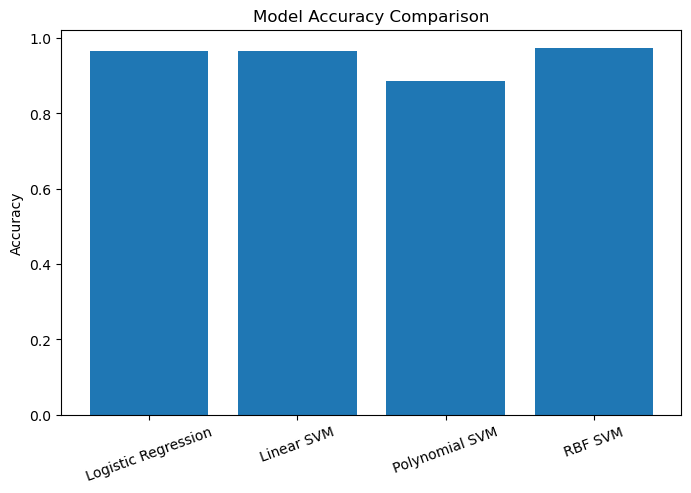

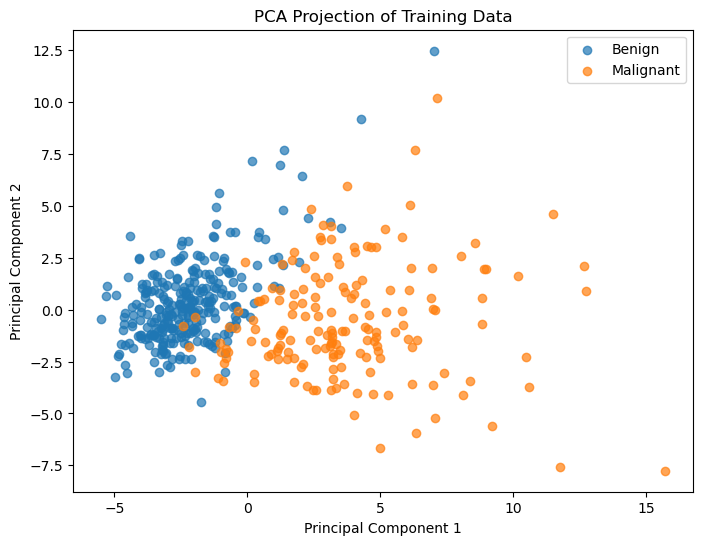

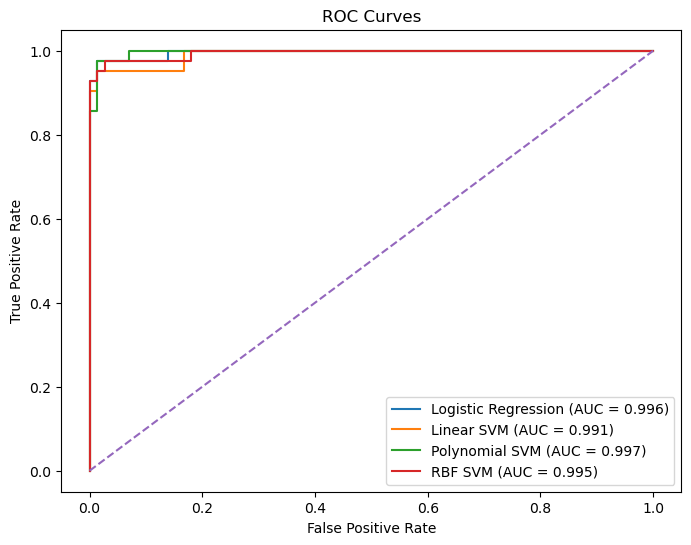

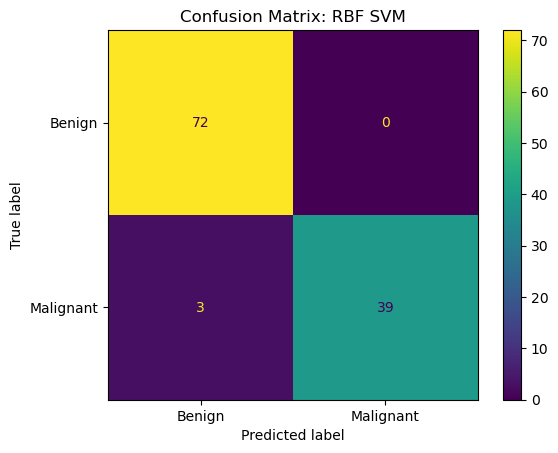

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
os.makedirs("figures", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc

# Load and clean data
df = pd.read_csv("Breast_cancer_dataset.csv")

if "id" in df.columns:
    df = df.drop(columns="id")
if "Unnamed: 32" in df.columns:
    df = df.drop(columns="Unnamed: 32")

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

X = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(X), columns=X.columns)

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": SVC(kernel="linear", probability=True),
    "Polynomial SVM": SVC(kernel="poly", degree=3, probability=True),
    "RBF SVM": SVC(kernel="rbf", probability=True)
}

results = {}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, pred)
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    results[name] = {"model": model, "accuracy": acc, "auc": roc_auc}

    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, pred, target_names=["Benign", "Malignant"]))

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), [r["accuracy"] for r in results.values()])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.savefig("figures/Accuracy_plot", dpi=300, bbox_inches="tight")
plt.show()

# PCA plot
X_pca = PCA(n_components=2).fit_transform(X_train)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y_train.values == 0, 0], X_pca[y_train.values == 0, 1], label="Benign", alpha=0.7)
plt.scatter(X_pca[y_train.values == 1, 0], X_pca[y_train.values == 1, 1], label="Malignant", alpha=0.7)
plt.title("PCA Projection of Training Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.savefig("figures/PCA_plot", dpi=300, bbox_inches="tight")
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
for name, r in results.items():
    prob = r["model"].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {r['auc']:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("figures/ROC_Curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion matrix for best model
best_name = max(results, key=lambda x: results[x]["accuracy"])
best_model = results[best_name]["model"]
best_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"]).plot()
plt.title(f"Confusion Matrix: {best_name}")
plt.savefig("figures/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()